In [1]:
! which python 

/home/zhanyu/anaconda3/envs/kaggle/bin/python


# 海航航段分配

## 实现几个函数来方便下载数据

In [2]:
import hashlib  # 导入哈希库，用于生成文件的SHA-1哈希值
import os       # 导入os库，用于文件路径和目录操作
import tarfile  # 导入tarfile库，用于解压tar格式文件
import zipfile  # 导入zipfile库，用于解压zip格式文件
import requests # 导入requests库，用于发送HTTP请求下载文件

# # 定义一个字典，用于存储数据集名称与对应的URL及哈希值
# DATA_HUB = dict()

# # 数据集的基础URL，用于下载数据
# DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

# # 返回的是本地文件路径
# def download(name, cache_dir=os.path.join('..', 'data')):  
#     """下载一个DATA_HUB中的文件，返回本地文件名。"""
#     # 确保要下载的文件名称在DATA_HUB字典中，否则报错
#     assert name in DATA_HUB, f"{name} 不存在于 {DATA_HUB}."
    
#     # 获取文件的URL和对应的SHA-1哈希值
#     url, sha1_hash = DATA_HUB[name]
    
#     # 创建缓存目录（如不存在），用于存放下载的文件
#     os.makedirs(cache_dir, exist_ok=True)
    
#     # 生成文件的本地路径，文件名取自URL的最后一部分
#     fname = os.path.join(cache_dir, url.split('/')[-1])
    
#     # 如果文件已经存在于缓存目录中，校验其哈希值以确定文件完整性
#     if os.path.exists(fname):
#         sha1 = hashlib.sha1()  # 创建一个SHA-1哈希对象
#         with open(fname, 'rb') as f:
#             # 逐块读取文件数据，避免一次性读入内存
#             while True:
#                 data = f.read(1048576)  # 每次读取1MB的数据块
#                 if not data:  # 如果没有数据可读，说明文件已读取完毕
#                     break
#                 sha1.update(data)  # 更新哈希对象的数据
#         # 如果本地文件的哈希值与DATA_HUB中记录的值相同，返回文件路径
#         if sha1.hexdigest() == sha1_hash:
#             return fname
    
#     # 如果文件不存在或哈希校验未通过，重新下载文件
#     print(f'正在从{url}下载{fname}...')
#     # 使用requests发送GET请求以流式方式下载文件
#     r = requests.get(url, stream=True, verify=True)
#     # 以二进制写模式打开文件，并将下载内容写入文件
#     with open(fname, 'wb') as f:
#         f.write(r.content)  # 将响应内容写入文件
#     return fname  # 返回本地文件路径

## 访问和读取数据集

使用2023全年的数据作为训练集，2024的数据作为测试集

In [15]:
%matplotlib inline 

import numpy as np  # 导入NumPy库，用于数组和矩阵计算
import pandas as pd  # 导入Pandas库，用于数据处理和分析
import glob # 用于匹配当前目录下的文件名模式
import torch  # 导入PyTorch库，用于构建和训练深度学习模型
from torch import nn  # 从torch中导入神经网络模块
from d2l import torch as d2l  # 从d2l库中导入PyTorch部分，提供深度学习工具

# # 将训练数据文件和测试数据文件的URL及其SHA-1哈希值存储在DATA_HUB字典中
# DATA_HUB['kaggle_house_train'] = (  
#     DATA_URL + 'kaggle_house_pred_train.csv',  # 训练数据的下载链接
#     '585e9cc93e70b39160e7921475f9bcd7d31219ce')  # 训练数据的SHA-1哈希值，用于校验文件完整性

# DATA_HUB['kaggle_house_test'] = (  
#     DATA_URL + 'kaggle_house_pred_test.csv',  # 测试数据的下载链接
#     'fa19780a7b011d9b009e8bff8e99922a8ee2eb90')  # 测试数据的SHA-1哈希值，用于校验文件完整性

# 航班基础数据加载为Pandas数据框
train_data = pd.read_csv('/home/zhanyu/experiment/data-hh/航班销售结果数据/mid_flt_segment_sum_tmp_202410241005.csv')


# 航班销售结果数据加载为Pandas数据框
test_data = pd.read_csv('/home/zhanyu/experiment/data-hh/航班销售结果数据/mid_flt_segment_sum_tmp_202410241006.csv')

# 打印训练数据和测试数据的形状（行数和列数），用于了解数据集大小
# 训练数据集包括1460个样本，每个样本80个特征和1个标签， 而测试数据集包含1459个样本，每个样本80个特征

# # 指定完整路径并匹配所有相关的 CSV 文件
# csv_files = glob.glob("/home/zhanyu/experiment/data-hh/航班销售结果数据/mid_flt_segment_sum_tmp_*.csv")

# # 创建一个空列表来存放每个 CSV 文件的数据框
# dataframes = []

# # 遍历所有匹配到的文件
# for file in csv_files:
#     # 读取 CSV 文件
#     df = pd.read_csv(file)
    
#     # 从文件名中提取日期信息（例如 202410241005）
#     date = file.split("_")[-1].split(".")[0]
    
#     # 添加日期列
#     df["date"] = date
    
#     # 将当前文件的数据框添加到数据框列表
#     dataframes.append(df)

# 使用 pd.concat 合并所有数据框
# train_data = pd.concat(dataframes, ignore_index=True)

print(train_data.shape)
print(test_data.shape)


(812968, 13)
(413777, 13)


In [16]:
# 第一行的数据以及数据段
    # mid_flt_segment_sum_tmp_202410241005.csv加载的是2023年全年的销售结果,812968条数据
    # mid_flt_segment_sum_tmp_202410241006.csv加载的是2024年1-1到6-30的销售结果,413777条数据
print('train')
print(train_data.shape)
print(train_data.iloc[0, :])

print("")
print('test_data')
print(test_data.shape)
print(test_data.iloc[0, :])

train
(812968, 13)
flt_date                   2023-01-01
a                        So/c8CkA/Xs=
b                        S3aBB6HqY4s=
c                        /qxKZMQeBus=
segment     S3aBB6HqY4s=-/qxKZMQeBus=
flt_no                   9sFh30Q0Yws=
aircraft                          32N
duration                          1.2
y_rev                          3714.0
y_pax                              13
y_cap                             167
c_rev                           167.0
c_pax                               0
Name: 0, dtype: object

test_data
(413777, 13)
flt_date                   2024-01-01
a                        XUXDuFGVfBM=
b                        07fT2dsZOJM=
c                        grkgazDvJmY=
segment     07fT2dsZOJM=-grkgazDvJmY=
flt_no                   6TJZneHazD4=
aircraft                          320
duration                          2.0
y_rev                         43350.0
y_pax                              78
y_cap                             168
c_rev                 

In [17]:
# 我们关注的是航段的比例，与rev无关，因此，在将数据提供给模型之前，我们将其从数据集中删除
# 删除倒数第5列
train_data = train_data.drop(train_data.columns[-5], axis=1)
# 删除倒数第3列
train_data = train_data.drop(train_data.columns[-3], axis=1)
train_data = train_data.drop(train_data.columns[-2], axis=1)


# 删除最后5列
test_data = test_data.drop(test_data.columns[-5:], axis=1)


# 列对齐：如果在拼接时，两个 DataFrame 的列不完全相同，Pandas 会按照列名进行对齐，不存在的列会填充为 NaN
all_features = pd.concat((train_data, test_data))


# train_data.iloc[:, 1:-1]：删除了ID列（第一列）和房价标签列（最后一列）后的训练集数据。
# test_data.iloc[:, 1:]：删除了ID列后的测试集数据。
# pd.concat()：将处理后的训练集和测试集特征数据按列合并，得到一个新的 all_features 数据框。


(1226745, 10)
flt_date                   2023-01-01
a                        So/c8CkA/Xs=
b                        S3aBB6HqY4s=
c                        /qxKZMQeBus=
segment     S3aBB6HqY4s=-/qxKZMQeBus=
flt_no                   9sFh30Q0Yws=
aircraft                          32N
duration                          1.2
y_pax                            13.0
c_pax                             0.0
Name: 0, dtype: object
flt_date                   2024-06-30
a                        9obCP1myMDU=
b                        FWD6O2fHsIU=
c                        KETr2NAmAHE=
segment     9obCP1myMDU=-KETr2NAmAHE=
flt_no                   axXT4g0vhyg=
aircraft                          320
duration                         3.27
y_pax                             NaN
c_pax                             NaN
Name: 413776, dtype: object


In [19]:
print(all_features.shape)
print(all_features.iloc[0, :])
print()
print(all_features.iloc[-1, :])

(1226745, 10)
flt_date                   2023-01-01
a                        So/c8CkA/Xs=
b                        S3aBB6HqY4s=
c                        /qxKZMQeBus=
segment     S3aBB6HqY4s=-/qxKZMQeBus=
flt_no                   9sFh30Q0Yws=
aircraft                          32N
duration                          1.2
y_pax                            13.0
c_pax                             0.0
Name: 0, dtype: object

flt_date                   2024-06-30
a                        9obCP1myMDU=
b                        FWD6O2fHsIU=
c                        KETr2NAmAHE=
segment     9obCP1myMDU=-KETr2NAmAHE=
flt_no                   axXT4g0vhyg=
aircraft                          320
duration                         3.27
y_pax                             NaN
c_pax                             NaN
Name: 413776, dtype: object


## 数据预处理

In [20]:
# 将所有缺失的值替换为相应特征的平均值。 通过将特征重新缩放到零均值和单位方差来标准化数据
# 选择所有数值类型的特征（即不包括类别型特征）
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index

# 对所有数值型特征进行标准化，即将每个特征的均值变为0，标准差变为1
# 使用apply函数对每个数值型特征列进行操作，lambda表达式表示每列数据减去均值并除以标准差
all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / (x.std()))
    
# 对所有数值型特征进行缺失值填充，填充的值是该特征列的均值（0）
all_features[numeric_features] = all_features[numeric_features].fillna(0)


In [21]:
print(all_features.shape)
print(all_features.iloc[0, :])
print()
print(all_features.iloc[-1, :])

(1226745, 10)
flt_date                   2023-01-01
a                        So/c8CkA/Xs=
b                        S3aBB6HqY4s=
c                        /qxKZMQeBus=
segment     S3aBB6HqY4s=-/qxKZMQeBus=
flt_no                   9sFh30Q0Yws=
aircraft                          32N
duration                    -1.258973
y_pax                       -1.751764
c_pax                       -0.386511
Name: 0, dtype: object

flt_date                   2024-06-30
a                        9obCP1myMDU=
b                        FWD6O2fHsIU=
c                        KETr2NAmAHE=
segment     9obCP1myMDU=-KETr2NAmAHE=
flt_no                   axXT4g0vhyg=
aircraft                          320
duration                      0.50585
y_pax                             0.0
c_pax                             0.0
Name: 413776, dtype: object


In [22]:
# 处理离散值。我们用一次独热编码替换它们
# pd.get_dummies() 用于将所有类别型（离散型）特征进行独热编码。
# 参数 dummy_na=True 表示将缺失值（NaN）也转换为一个新的列，表示是否为缺失值。
all_features = pd.get_dummies(all_features, dummy_na=True)

# 输出转换后的数据框的形状（行数和列数），查看独热编码后的结果
all_features.shape

(1226745, 8394)

In [23]:
# 获取训练集的样本数量（行数）
n_train = train_data.shape[0]

# 提取训练集特征并转换为PyTorch张量
# all_features[:n_train].values 选取所有特征的前 n_train 行作为训练集的特征
# .astype(float) 将数据转换为浮点型，以确保数据格式一致
# torch.tensor(..., dtype=torch.float32) 将数据转换为32位浮点数格式的PyTorch张量
train_features = torch.tensor(all_features[:n_train].values.astype(float), dtype=torch.float32)

# 提取测试集特征并转换为PyTorch张量
# all_features[n_train:].values 选取所有特征的从第 n_train 行开始的所有行，作为测试集的特征
# .astype(float) 将数据转换为浮点型
# torch.tensor(..., dtype=torch.float32) 将数据转换为32位浮点数格式的PyTorch张量
test_features = torch.tensor(all_features[n_train:].values.astype(float), dtype=torch.float32)

# 提取训练集标签（房价）并转换为PyTorch张量
# train_data.SalePrice.values 获取训练集标签列（房价）的数值
# .astype(float).reshape(-1, 1) 将数据转换为浮点型并重塑为列向量（每行一个房价标签）
# torch.tensor(..., dtype=torch.float32) 将标签转换为32位浮点数格式的PyTorch张量
train_labels = torch.tensor(
    train_data.SalePrice.values.astype(float).reshape(-1, 1), dtype=torch.float32)

AttributeError: 'DataFrame' object has no attribute 'SalePrice'

## 训练

In [9]:
# 定义均方误差（MSE）损失函数，用于回归问题，计算预测值与真实值的平方差平均值
loss = nn.MSELoss()

# 获取输入特征的维度（列数），用于设置神经网络线性层的输入大小
in_features = train_features.shape[1]

# 定义一个简单的神经网络模型，包含一个输入层和一个输出层
def get_net():
    # nn.Sequential 创建顺序容器模型，这里包含一个线性层
    # nn.Linear(in_features, 1) 表示从输入特征数映射到1个输出值
    net = nn.Sequential(nn.Linear(in_features, 1))
    return net

# 定义计算对数均方根误差（log RMSE）的函数
# 我们更关心预测误差的相对大小，而不是绝对误差，因此使用对数来衡量差异
def log_rmse(net, features, labels):
    # 使用 torch.clamp 将预测值限制为不小于1，以避免对数计算中的负数和无穷大问题
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    # 计算对数均方根误差：先取对数再计算均方误差，最后开方
    rmse = torch.sqrt(loss(torch.log(clipped_preds),
                           torch.log(labels)))
    # 返回误差值（标量），用于模型评估
    return rmse.item()

# 定义模型训练函数，使用Adam优化算法进行优化
def train(net, train_features, train_labels, test_features, test_labels,
          num_epochs, learning_rate, weight_decay, batch_size):
    # 初始化用于存储训练误差和测试误差的列表
    train_ls, test_ls = [], []
    
    # 将训练特征和标签数据按批量大小加载到数据迭代器中，以便进行小批量训练
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    
    # 使用 Adam 优化器来更新网络参数，设置学习率和权重衰减
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr=learning_rate,
                                 weight_decay=weight_decay)
    
    # 训练过程，循环执行每个 epoch
    for epoch in range(num_epochs):
        # 遍历每个小批量数据
        for X, y in train_iter:
            optimizer.zero_grad()  # 清除梯度
            l = loss(net(X), y)    # 计算当前批量的损失
            l.backward()           # 反向传播计算梯度
            optimizer.step()       # 优化器更新模型参数
        
        # 每个 epoch 结束后，计算训练集上的对数均方根误差并记录
        train_ls.append(log_rmse(net, train_features, train_labels))
        
        # 如果有测试集，计算测试集上的对数均方根误差并记录
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    
    # 返回训练误差和测试误差（按 epoch 记录）
    return train_ls, test_ls


## k折交叉验证

In [10]:
# 获取第i折的训练集和验证集数据
def get_k_fold_data(k, i, X, y):
    # 确保 k > 1，因为至少需要两个折
    assert k > 1
    # 计算每折数据的大小
    fold_size = X.shape[0] // k
    # 初始化训练集特征和标签为空
    X_train, y_train = None, None
    for j in range(k):
        # 使用切片选择第 j 折的数据
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:  # 第 i 折作为验证集
            X_valid, y_valid = X_part, y_part
        elif X_train is None:  # 初始化训练集为第一个非验证折
            X_train, y_train = X_part, y_part
        else:  # 将其他折的数据追加到训练集
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    # 返回训练集和验证集的数据
    return X_train, y_train, X_valid, y_valid

# 执行 K 折交叉验证并计算训练和验证误差的平均值
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay,
           batch_size):
    # 初始化训练和验证误差的累积值
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        # 获取第 i 折的训练和验证数据
        data = get_k_fold_data(k, i, X_train, y_train)
        # 获取新的网络模型
        net = get_net()
        # 使用第 i 折的数据训练模型并获取误差
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate,
                                   weight_decay, batch_size)
        # 累加最后一个 epoch 的训练和验证误差
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        
        # 在第一个折上绘制训练和验证误差的曲线图
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                     legend=['train', 'valid'], yscale='log')
        
        # 输出当前折的训练和验证误差
        print(f'折{i + 1}，训练log rmse{float(train_ls[-1]):f}, '
              f'验证log rmse{float(valid_ls[-1]):f}')
    
    # 返回训练和验证误差的平均值
    return train_l_sum / k, valid_l_sum / k


## 模型选择

折1，训练log rmse0.167386, 验证log rmse0.164041
折2，训练log rmse0.166159, 验证log rmse0.144234
折3，训练log rmse0.166259, 验证log rmse0.157241
折4，训练log rmse0.159561, 验证log rmse0.226422
折5，训练log rmse0.160982, 验证log rmse0.195332
折6，训练log rmse0.165431, 验证log rmse0.130610
折7，训练log rmse0.167375, 验证log rmse0.139377
折8，训练log rmse0.163660, 验证log rmse0.165097
折9，训练log rmse0.161908, 验证log rmse0.204438
折10，训练log rmse0.165268, 验证log rmse0.152650
10-折验证: 平均训练log rmse: 0.164399, 平均验证log rmse: 0.167944


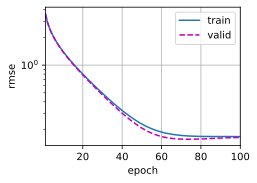

In [11]:
# 设置 K 折交叉验证的超参数
#k = 5：设置交叉验证的折数为5，即将数据分为5份，每次使用其中一份作为验证集，其余四份作为训练集。
#num_epochs = 100：设置模型训练的总轮数为100。
#lr = 5：设置学习率为5，控制模型参数的更新步长。
#weight_decay = 0：设置权重衰减系数（正则化参数）为0，即不使用正则化。
#batch_size = 64：设置小批量梯度下降的批量大小为64。
k, num_epochs, lr, weight_decay, batch_size = 10, 100, 5, 0, 64

# 使用 K 折交叉验证来评估模型性能，返回训练误差和验证误差的平均值
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                          weight_decay, batch_size)

# 打印 K 折验证结果，输出训练集和验证集上的平均对数均方根误差
print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, '
      f'平均验证log rmse: {float(valid_l):f}')


这里我有点点问题，为什么valid的损失会比train的小

## 提交Kaggle预测

In [12]:
def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
             ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    print(f'训练log rmse：{float(train_ls[-1]):f}')
    # 将网络应用于测试集。
    preds = net(test_features).detach().numpy()
    # 将其重新格式化以导出到Kaggle
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv', index=False)

训练log rmse：0.162919


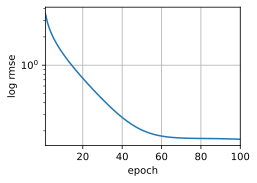

In [13]:
train_and_pred(train_features, test_features, train_labels, test_data,
               num_epochs, lr, weight_decay, batch_size)